Data shape: (4200, 12)
[[ 1.85e+03  1.00e+00 -7.53e-01  3.65e-01       nan       nan       nan
        nan       nan       nan       nan       nan]
 [ 1.85e+03  2.00e+00 -2.02e-01  4.16e-01       nan       nan       nan
        nan       nan       nan       nan       nan]
 [ 1.85e+03  3.00e+00 -3.67e-01  3.73e-01       nan       nan       nan
        nan       nan       nan       nan       nan]
 [ 1.85e+03  4.00e+00 -5.96e-01  3.24e-01       nan       nan       nan
        nan       nan       nan       nan       nan]
 [ 1.85e+03  5.00e+00 -6.19e-01  2.67e-01       nan       nan       nan
        nan       nan       nan       nan       nan]]
Number of annual values: 35
Warming rate: 0.228 ± 0.018 °C/decade


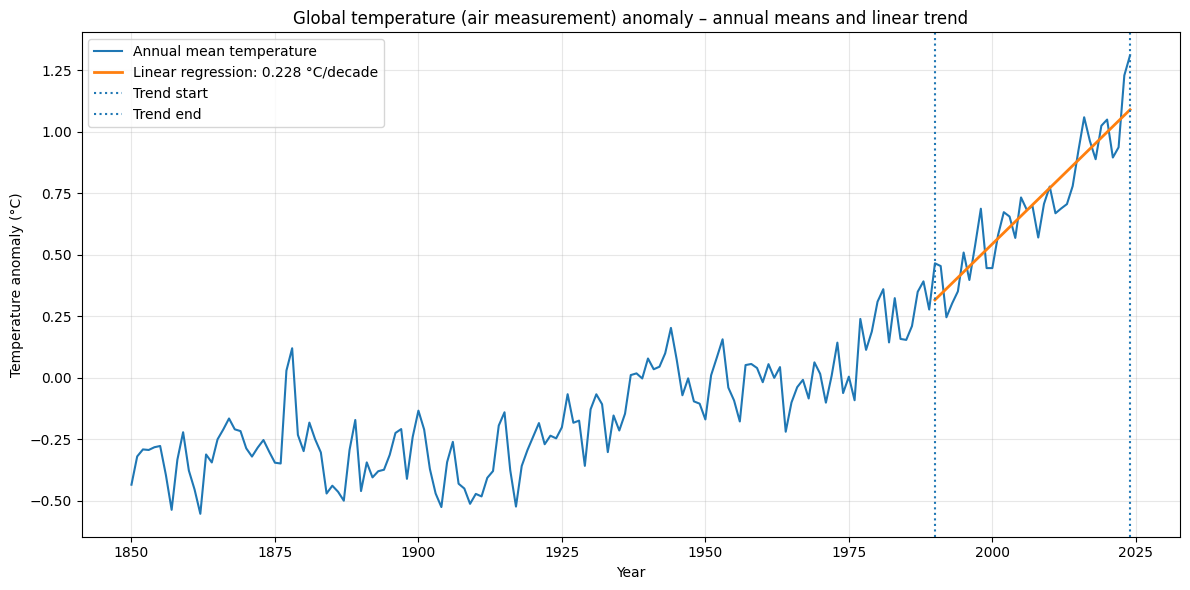

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

filename = "data/barkley_data.txt"

data = np.loadtxt(filename, comments='%')

print("Data shape:", data.shape)
print(data[:5])

use_air_temp_data = True

if use_air_temp_data:
    data = data[:len(data)//2]       # Air temperature
else:
    data = data[len(data)//2:]       # Water temperature

year = data[:, 0]
month = data[:, 1]
temperature = data[:, 2]
uncertainty = data[:, 3]

# --------------------------------------------------
# Calculate annual mean temperature
# --------------------------------------------------

year_unique = np.unique(year)

annual_mean_temperature = np.array([
    np.mean(temperature[year == y])
    for y in year_unique
])

# --------------------------------------------------
# Linear regression
# --------------------------------------------------

time = year_unique

win_start = 1990
win_end = 2024

mask = (time >= win_start) & (time <= win_end)

time_window = time[mask]
temperature_window = annual_mean_temperature[mask]

print(f"Number of annual values: {len(time_window)}")

result = linregress(time_window, temperature_window)

slope = result.slope
intercept = result.intercept
slope_uncertainty = result.stderr

warming_rate = slope * 10
warming_uncertainty = slope_uncertainty * 10

print(
    f"Warming rate: {warming_rate:.3f} ± "
    f"{warming_uncertainty:.3f} °C/decade"
)

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(12, 6))

# Annual mean temperature
plt.plot(
    time,
    annual_mean_temperature,
    linewidth=1.5,
    label="Annual mean temperature"
)

# Linear regression
linear_fit = slope * time_window + intercept
plt.plot(
    time_window,
    linear_fit,
    linewidth=2,
    label=f"Linear regression: {warming_rate:.3f} °C/decade"
)

# Vertical lines showing the linear trend period
plt.axvline(
    win_start,
    linestyle=":",
    linewidth=1.5,
    label="Trend start"
)

plt.axvline(
    win_end,
    linestyle=":",
    linewidth=1.5,
    label="Trend end"
)

plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")

plt.title(
    "Global temperature (air measurement) anomaly – annual means and linear trend"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(
    "temperature_linear_trend_1990.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()